# 03 Exploratory Data Analysis

Use this notebook to explore trends, distributions, segments, anomalies, and early business signals.

In [20]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns


PALETTE = ["#2563EB", "#DC2626"]          # blue = not readmitted, red = readmitted
ACCENT  = "#2563EB"
sns.set_theme(style="whitegrid", font_scale=1.15)
plt.rcParams["figure.dpi"] = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().resolve().name == 'notebooks' else Path.cwd().resolve()
FIGURES_DIR  = PROJECT_ROOT / "reports" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


In [17]:
DATA_PATH = DATA_PATH = 'https://raw.githubusercontent.com/pushkar-bit/Section-E_G-19_Healthcare-Patient-Readmission-Intelligence/main/data/processed/cleaned_hospital_readmissions.csv'
df = pd.read_csv(DATA_PATH)
df.head()

,age,time_in_hospital,n_lab_procedures,n_procedures,n_medications,n_outpatient,n_inpatient,n_emergency,medical_specialty,diag_1,...,total_visits,is_frequent_patient,stay_intensity,procedures_per_day,meds_per_visit,service_utilization_score,length_of_stay_bucket,age_numeric,age_group,is_senior
0,3,8,72,1,18,2,0,0,4,0,...,2,0,576,0,9,34.5,0,75.0,3,1
1,3,3,34,2,13,0,0,0,5,6,...,0,0,102,1,13,18.1,2,75.0,3,1
2,1,5,45,0,18,0,0,0,4,0,...,0,0,225,0,18,23.4,1,55.0,2,0
3,3,2,36,0,12,1,0,0,4,0,...,1,0,72,0,12,18.0,2,75.0,3,1
4,2,1,42,0,7,0,0,0,3,6,...,0,0,42,0,7,18.9,2,65.0,3,1


In [18]:
df.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
age,25000.0,2.344120,1.315633,0.0,1.0,2.0,3.0,5.0
time_in_hospital,25000.0,4.453320,3.001470,1.0,2.0,4.0,6.0,14.0
n_lab_procedures,25000.0,43.240760,19.818620,1.0,31.0,44.0,57.0,113.0
n_procedures,25000.0,1.352360,1.715179,0.0,0.0,1.0,2.0,6.0
n_medications,25000.0,16.252400,8.060532,1.0,11.0,15.0,20.0,79.0
n_outpatient,25000.0,0.366400,1.195478,0.0,0.0,0.0,0.0,33.0
n_inpatient,25000.0,0.615960,1.177951,0.0,0.0,0.0,1.0,15.0
n_emergency,25000.0,0.186600,0.885873,0.0,0.0,0.0,0.0,64.0
medical_specialty,25000.0,3.458800,1.425449,0.0,3.0,4.0,4.0,6.0
diag_1,25000.0,3.297080,2.827781,0.0,0.0,3.0,6.0,7.0


In [ ]:
# Replace the example columns below with project-specific columns.
# sns.histplot(data=df, x='numeric_column')
# plt.show()

## 1) Target variable — class balance

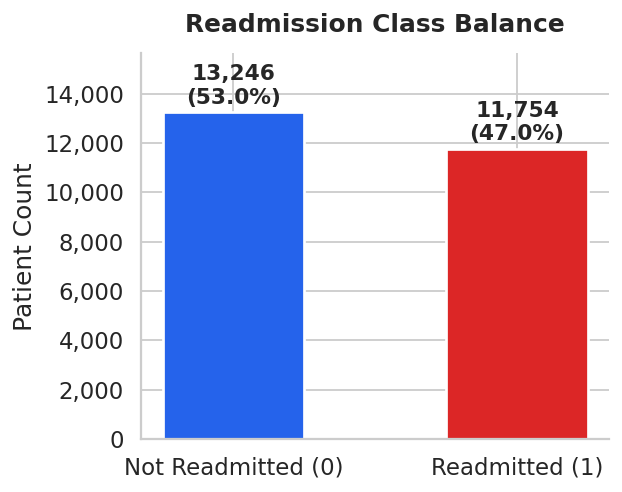


Readmission rate: 47.0%


In [25]:
import matplotlib.ticker as mticker

# --- Prepare data ---
target_counts = df["readmitted_30_days"].value_counts().sort_index()
target_pct = (target_counts / len(df) * 100).round(1)

labels = ["Not Readmitted (0)", "Readmitted (1)"]

# --- Create plot ---
fig, ax = plt.subplots(figsize=(5, 4))

bars = ax.bar(
    labels,
    target_counts.values,
    color=PALETTE,
    edgecolor="white",
    linewidth=1.5,
    width=0.5
)

# --- Add text labels on bars ---
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    x_pos = bar.get_x() + bar.get_width() / 2
    y_pos = bar.get_height()

    ax.text(
        x_pos,
        y_pos + 200,
        f"{count:,}\n({pct}%)",
        ha="center",
        va="bottom",
        fontsize=12,
        fontweight="bold"
    )

# --- Styling ---
ax.set_title("Readmission Class Balance", fontweight="bold", pad=12)
ax.set_ylabel("Patient Count")

# Format y-axis with commas (e.g., 10,000)
ax.yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f"{int(x):,}")
)

ax.set_ylim(0, target_counts.max() * 1.18)

# --- Save & show ---
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_01_target_balance.png", bbox_inches="tight")
plt.show()

# --- Print summary ---
print(f"\nReadmission rate: {target_pct[1]}%")
# print("⚠️  Mild class imbalance — monitor precision/recall in modelling notebook.")

## 2) Univariate distributions — continuous variables


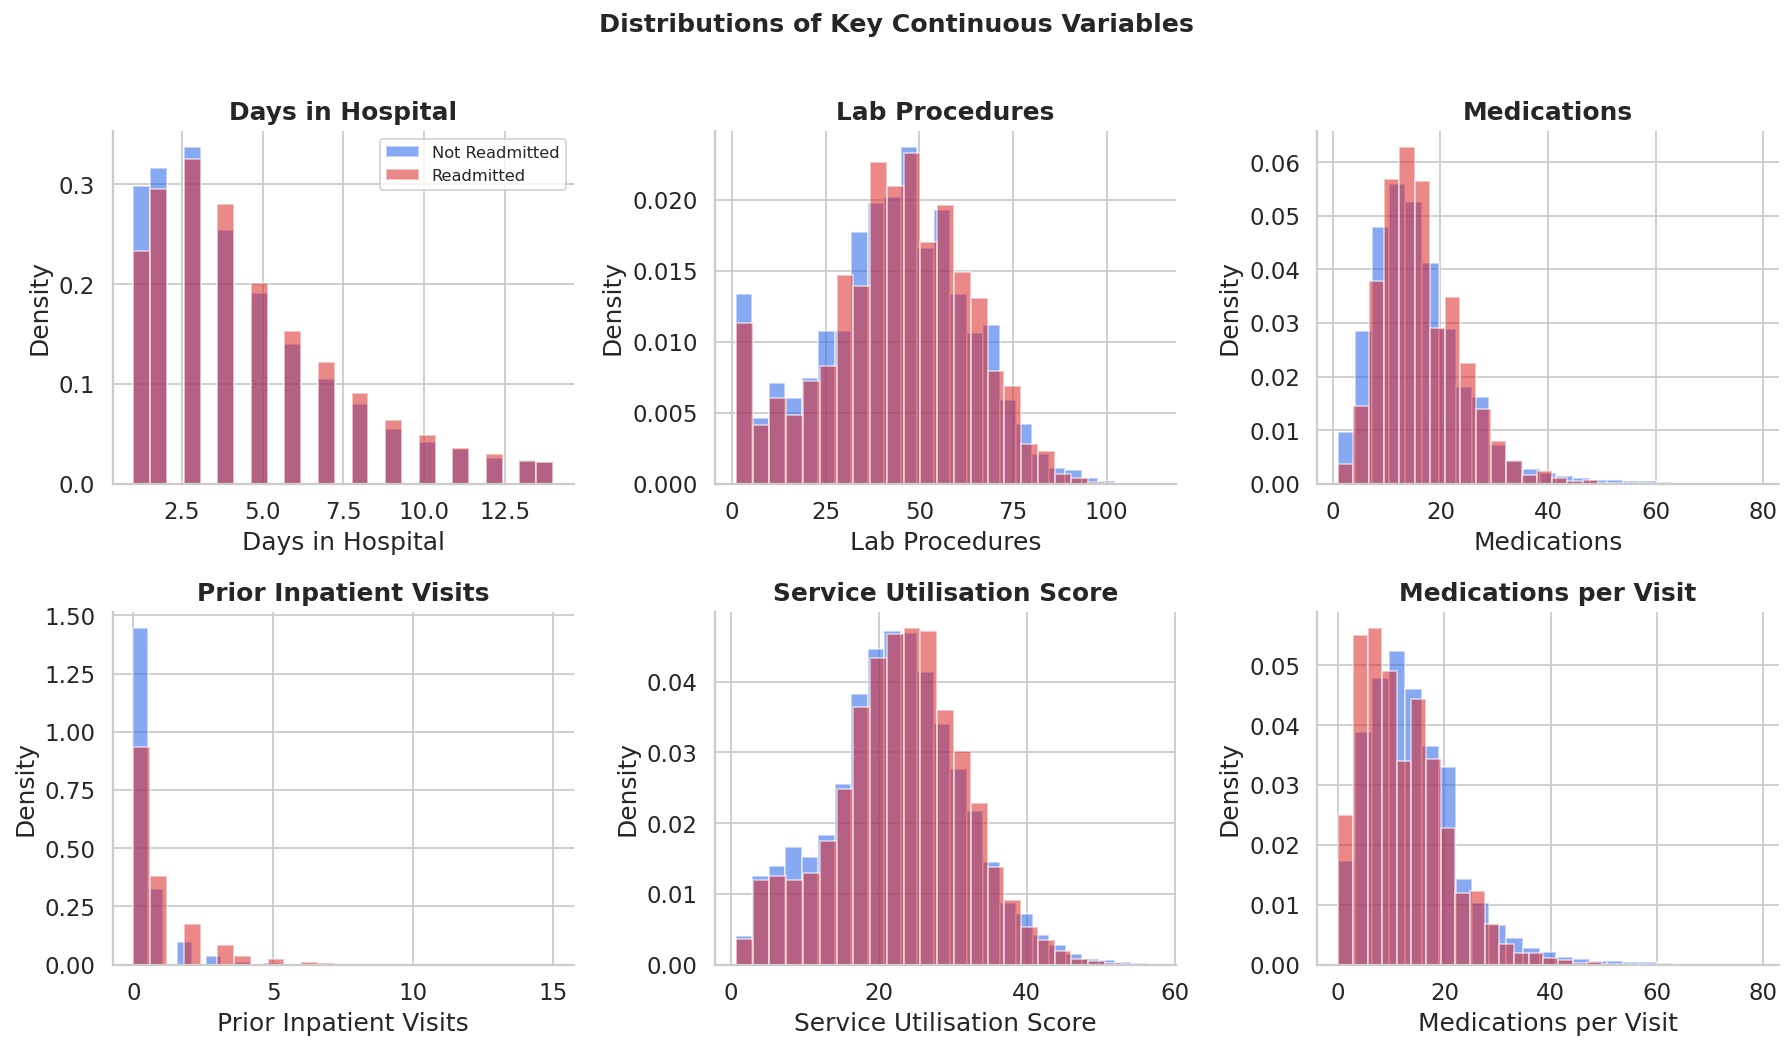

In [28]:
# Variables to plot (column name, display label)
cont_vars = [
    ("time_in_hospital", "Days in Hospital"),
    ("n_lab_procedures", "Lab Procedures"),
    ("n_medications", "Medications"),
    ("n_inpatient", "Prior Inpatient Visits"),
    ("service_utilization_score", "Service Utilisation Score"),
    ("meds_per_visit", "Medications per Visit"),
]

# Create figure
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distributions of Key Continuous Variables", fontsize=14, fontweight="bold", y=1.01)

# Loop through each variable
for ax, (col, label) in zip(axes.flat, cont_vars):

    # Plot for both classes
    for cls in [0, 1]:
        data = df[df["readmitted_30_days"] == cls][col].dropna()
        color = PALETTE[cls]
        name = "Not Readmitted" if cls == 0 else "Readmitted"

        ax.hist(data, bins=25, color=color, alpha=0.55, density=True, label=name)

    # Labels
    ax.set_title(label, fontweight="bold")
    ax.set_xlabel(label)
    ax.set_ylabel("Density")

# Add legend only once
axes.flat[0].legend(fontsize=9)

# Save and show
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_02_univariate_distributions.png", bbox_inches="tight")
plt.show()

## 3) Bivariate — readmission rate by categorical predictors

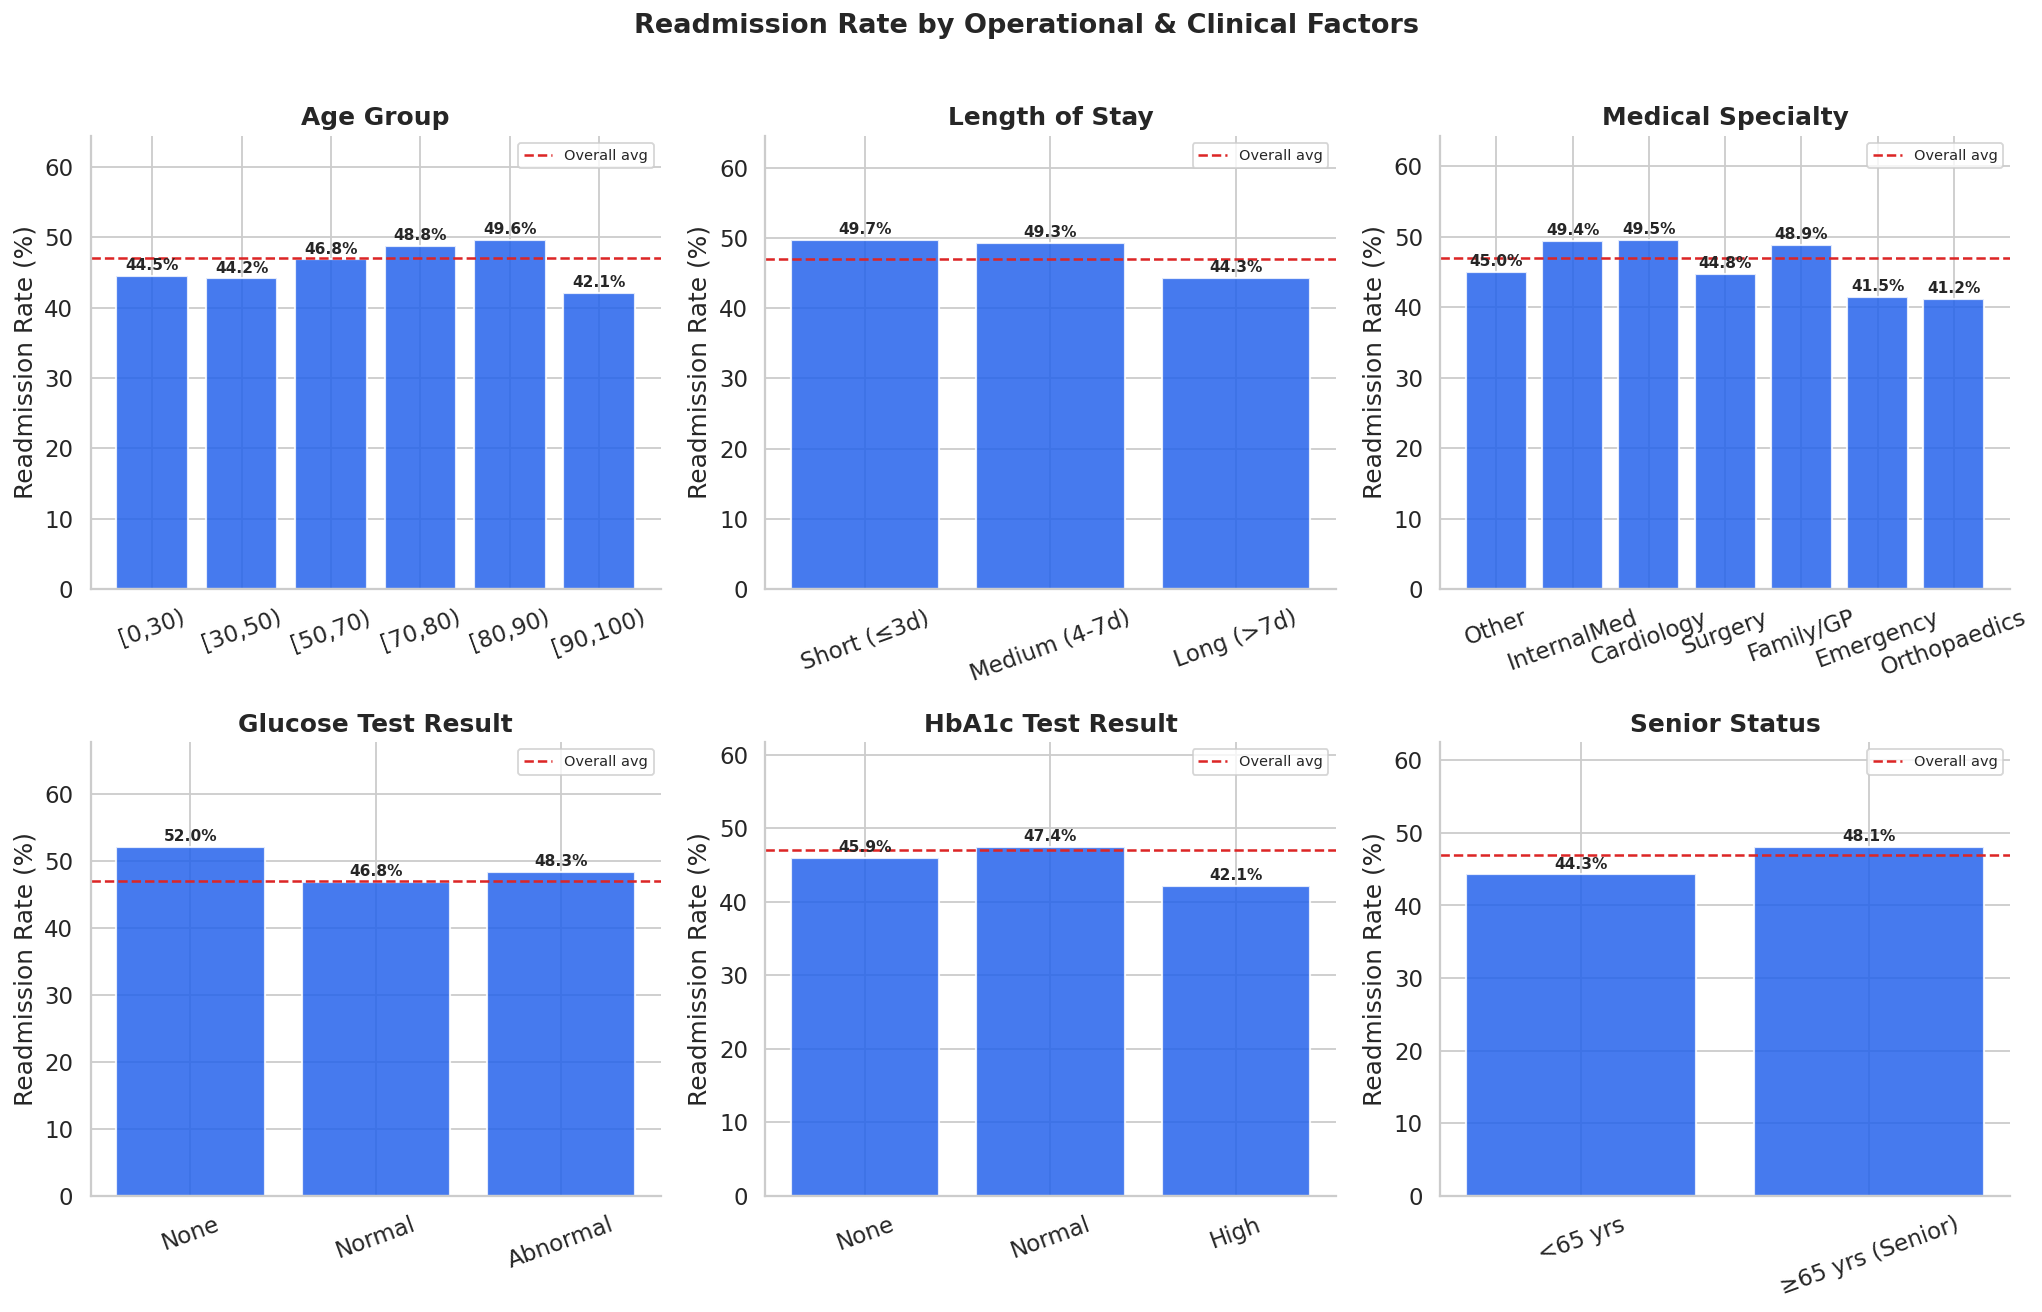

In [32]:
# --- Label maps ---
AGE_LABELS = {0: "[0,30)", 1: "[30,50)", 2: "[50,70)", 3: "[70,80)", 4: "[80,90)", 5: "[90,100)"}
LOS_LABELS = {0: "Short (≤3d)", 1: "Medium (4-7d)", 2: "Long (>7d)"}
MED_SPEC_LABELS = {0: "Other", 1: "InternalMed", 2: "Cardiology", 3: "Surgery", 4: "Family/GP", 5: "Emergency", 6: "Orthopaedics"}
GLUCOSE_LABELS = {0: "None", 1: "Normal", 2: "Abnormal"}
A1C_LABELS = {0: "None", 1: "Normal", 2: "High"}

# (column, label_map, title)
cat_specs = [
    ("age", AGE_LABELS, "Age Group"),
    ("length_of_stay_bucket", LOS_LABELS, "Length of Stay"),
    ("medical_specialty", MED_SPEC_LABELS, "Medical Specialty"),
    ("glucose_test", GLUCOSE_LABELS, "Glucose Test Result"),
    ("a1ctest", A1C_LABELS, "HbA1c Test Result"),
    ("is_senior", {0: "<65 yrs", 1: "≥65 yrs (Senior)"}, "Senior Status"),
]

# --- Create figure ---
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Readmission Rate by Operational & Clinical Factors",
             fontsize=15, fontweight="bold", y=1.01)

overall_rate = df["readmitted_30_days"].mean() * 100  # calculate once

# --- Plot each category ---
for ax, (col, label_map, title) in zip(axes.flat, cat_specs):

    # Calculate readmission rate per group
    rates = df.groupby(col)["readmitted_30_days"].mean().reset_index()
    rates.columns = ["group", "readmit_rate"]

    # Convert numeric codes to readable labels
    rates["label"] = rates["group"].map(label_map)
    rates["label"] = rates["label"].fillna(rates["group"].astype(str))

    # Plot bars
    bars = ax.bar(
        rates["label"],
        rates["readmit_rate"] * 100,
        color=ACCENT,
        edgecolor="white",
        linewidth=1.2,
        alpha=0.85
    )

    # Add overall average line
    ax.axhline(overall_rate, color="#DC2626", linestyle="--", linewidth=1.4, label="Overall avg")

    # Add percentage labels on bars
    for bar, rate in zip(bars, rates["readmit_rate"]):
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_height()

        ax.text(
            x, y + 0.4,
            f"{rate * 100:.1f}%",
            ha="center",
            va="bottom",
            fontsize=8.5,
            fontweight="bold"
        )

    # Styling
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Readmission Rate (%)")
    ax.set_ylim(0, rates["readmit_rate"].max() * 130)
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)

# --- Final layout ---
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_03_readmission_by_category.png", bbox_inches="tight")
plt.show()

## 4) Prior utilisation vs readmission — the strongest continuous signal


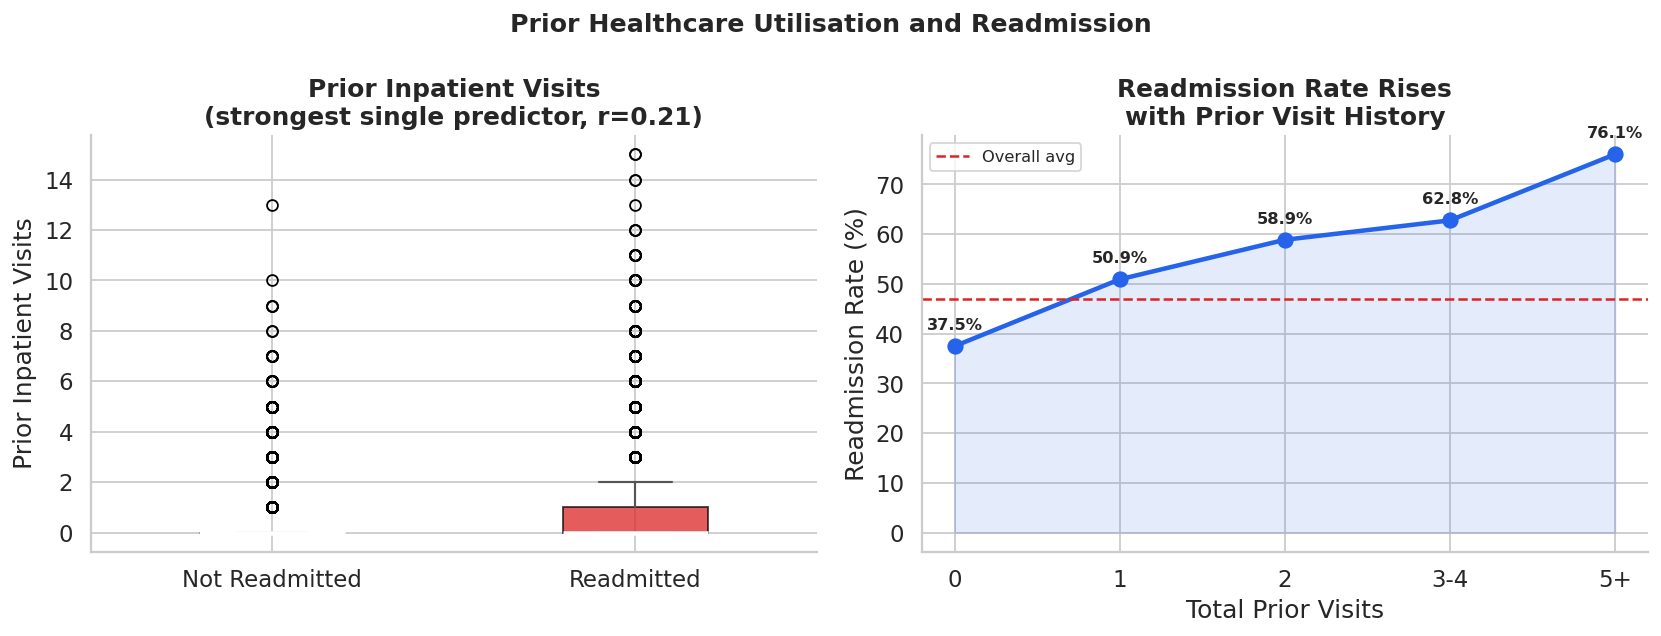

In [33]:
# --- Create figure ---
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle("Prior Healthcare Utilisation and Readmission",
             fontsize=14, fontweight="bold")

# =========================
# 1. Box Plot
# =========================
ax = axes[0]

not_readmitted = df[df["readmitted_30_days"] == 0]["n_inpatient"]
readmitted = df[df["readmitted_30_days"] == 1]["n_inpatient"]

data = [not_readmitted, readmitted]

boxplot = ax.boxplot(
    data,
    patch_artist=True,
    widths=0.4,
    medianprops={"color": "white", "linewidth": 2.5}
)

# Color the boxes
for box, color in zip(boxplot["boxes"], PALETTE):
    box.set_facecolor(color)
    box.set_alpha(0.75)

# Style whiskers and caps
for whisker in boxplot["whiskers"]:
    whisker.set(color="#555", linewidth=1.2)

for cap in boxplot["caps"]:
    cap.set(color="#555", linewidth=1.2)

# Labels
ax.set_xticks([1, 2])
ax.set_xticklabels(["Not Readmitted", "Readmitted"])
ax.set_ylabel("Prior Inpatient Visits")
ax.set_title(
    "Prior Inpatient Visits\n(strongest single predictor, r=0.21)",
    fontweight="bold"
)

# =========================
# 2. Line Plot
# =========================
ax = axes[1]

# Create visit buckets
df["total_visits_bucket"] = pd.cut(
    df["total_visits"],
    bins=[-1, 0, 1, 2, 4, 20],
    labels=["0", "1", "2", "3-4", "5+"]
)

# Compute readmission rate
visit_rates = (
    df.groupby("total_visits_bucket", observed=True)["readmitted_30_days"]
    .mean() * 100
)

# Plot line
x = range(len(visit_rates))
y = visit_rates.values

ax.plot(x, y, marker="o", color=ACCENT, linewidth=2.5, markersize=8)
ax.fill_between(x, y, alpha=0.12, color=ACCENT)

# Overall average line
overall_avg = df["readmitted_30_days"].mean() * 100
ax.axhline(overall_avg, color="#DC2626", linestyle="--",
           linewidth=1.4, label="Overall avg")

# Add value labels
for i, value in enumerate(y):
    ax.annotate(
        f"{value:.1f}%",
        (i, value),
        textcoords="offset points",
        xytext=(0, 9),
        ha="center",
        fontsize=9,
        fontweight="bold"
    )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(visit_rates.index.astype(str))
ax.set_xlabel("Total Prior Visits")
ax.set_ylabel("Readmission Rate (%)")
ax.set_title("Readmission Rate Rises\nwith Prior Visit History",
             fontweight="bold")
ax.legend(fontsize=9)

# =========================
# Final
# =========================
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_04_prior_utilisation.png", bbox_inches="tight")
plt.show()

## 5) Correlation heatmap — numeric features


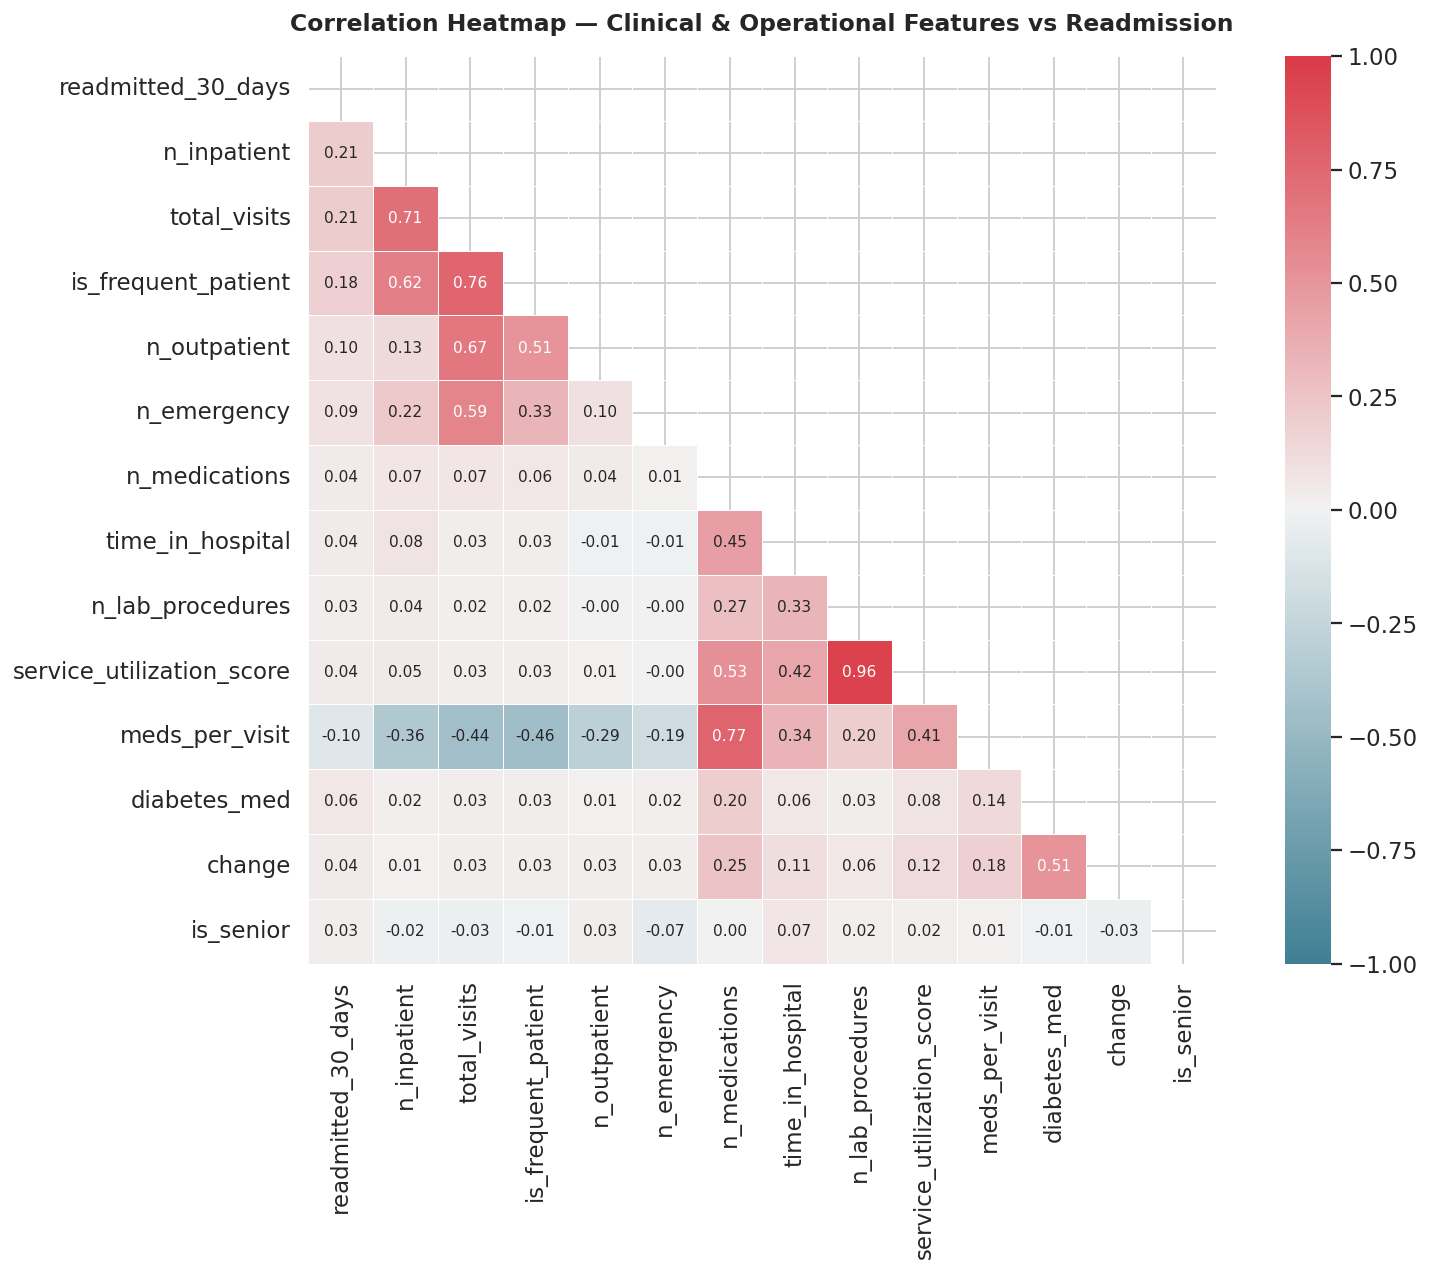

Top correlates with readmitted_30_days:
n_inpatient            0.21
total_visits           0.21
is_frequent_patient    0.18
n_outpatient           0.10
meds_per_visit        -0.10
n_emergency            0.09
diabetes_med           0.06
n_medications          0.04
time_in_hospital       0.04
change                 0.04
Name: readmitted_30_days, dtype: float64


In [34]:
# --- Columns for correlation ---
heat_cols = [
    "readmitted_30_days",
    "n_inpatient",
    "total_visits",
    "is_frequent_patient",
    "n_outpatient",
    "n_emergency",
    "n_medications",
    "time_in_hospital",
    "n_lab_procedures",
    "service_utilization_score",
    "meds_per_visit",
    "diabetes_med",
    "change",
    "is_senior",
]

# --- Compute correlation matrix ---
corr_matrix = df[heat_cols].corr().round(2)

# --- Create mask (hide upper triangle) ---
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

# --- Plot heatmap ---
fig, ax = plt.subplots(figsize=(13, 10))

sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=sns.diverging_palette(220, 10, as_cmap=True),
    vmin=-1,
    vmax=1,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 8.5},
    linewidths=0.5,
    square=True,
    ax=ax
)

# --- Title & layout ---
ax.set_title(
    "Correlation Heatmap — Clinical & Operational Features vs Readmission",
    fontsize=13,
    fontweight="bold",
    pad=14
)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_05_correlation_heatmap.png", bbox_inches="tight")
plt.show()

# --- Top correlations with target ---
print("Top correlates with readmitted_30_days:")

top_corr = (
    corr_matrix["readmitted_30_days"]
    .drop("readmitted_30_days")
    .sort_values(key=abs, ascending=False)
    .head(10)
)

print(top_corr)

## 6) Medical specialty deep-dive — readmission rate + volume

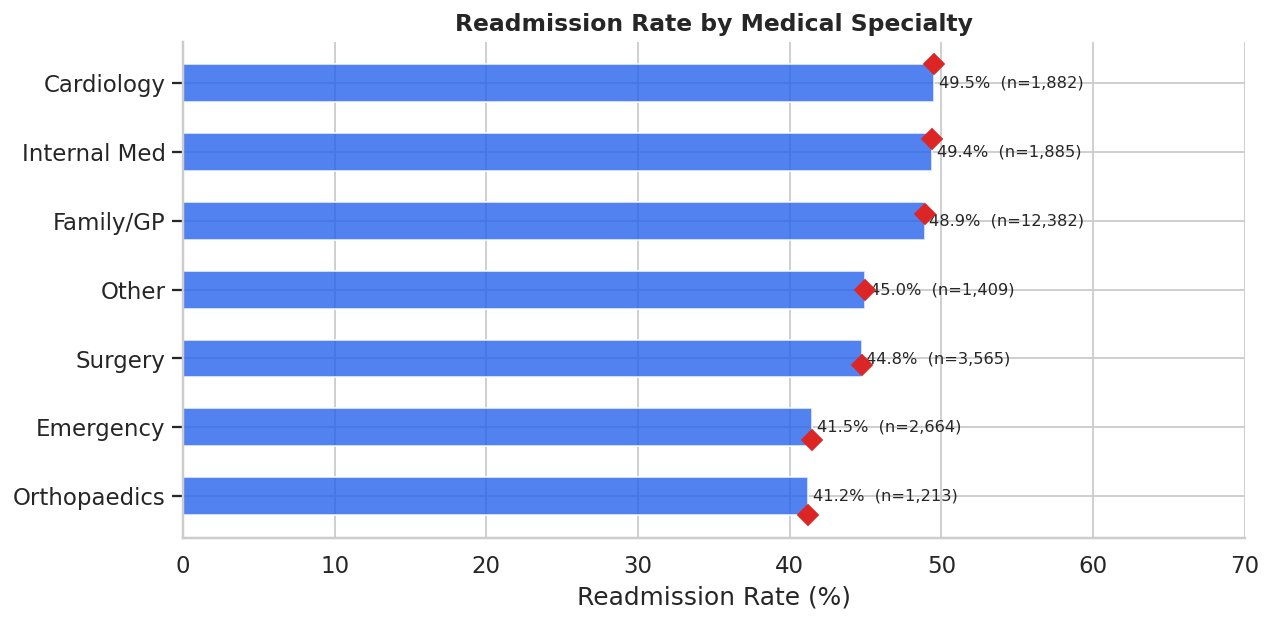

In [35]:
# --- Label map ---
spec_map = {
    0: "Other",
    1: "Internal Med",
    2: "Cardiology",
    3: "Surgery",
    4: "Family/GP",
    5: "Emergency",
    6: "Orthopaedics"
}

# --- Compute stats ---
spec_stats = (
    df.groupby("medical_specialty")
    .agg(
        count=("readmitted_30_days", "count"),
        readmit_rate=("readmitted_30_days", "mean")
    )
    .reset_index()
)

# Add readable labels and sort
spec_stats["label"] = spec_stats["medical_specialty"].map(spec_map)
spec_stats = spec_stats.sort_values("readmit_rate")

# --- Create plot ---
fig, ax1 = plt.subplots(figsize=(10, 5))
ax2 = ax1.twinx()

# Horizontal bars (readmission rate)
rates = spec_stats["readmit_rate"] * 100
labels = spec_stats["label"]
counts = spec_stats["count"]

bars = ax1.barh(labels, rates, color=ACCENT, alpha=0.8, height=0.55)

# Overlay markers
ax2.plot(rates, labels, "D", color="#DC2626", markersize=8, zorder=5)

# Add text labels
for bar, rate, count in zip(bars, rates, counts):
    x = bar.get_width()
    y = bar.get_y() + bar.get_height() / 2

    ax1.text(
        x + 0.3,
        y,
        f"{rate:.1f}%  (n={count:,})",
        va="center",
        fontsize=9
    )

# --- Styling ---
ax1.set_xlabel("Readmission Rate (%)")
ax1.set_xlim(0, 70)
ax2.set_yticks([])

ax1.set_title("Readmission Rate by Medical Specialty",
              fontsize=13, fontweight="bold")

# --- Final ---
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_06_specialty_readmission.png", bbox_inches="tight")
plt.show()

## 7) EDA Summary

| Finding | Detail |
|---|---|
| **Class balance** | 47.0% readmitted — near-balanced; minimal oversampling needed |
| **Strongest predictor** | `n_inpatient` (r = 0.21), `total_visits` (r = 0.21), `is_frequent_patient` (r = 0.18) |
| **Age effect** | Readmission peaks in the 80-90 age band (~49.6%) |
| **Length of stay** | Counter-intuitively, shorter stays show slightly higher readmission — possible premature discharge signal |
| **Specialty** | Emergency and Cardiology have the highest readmission rates |
| **Diabetes medication** | Patients on diabetes medication have a meaningfully higher readmission rate (χ² p < 0.0001) |
| **Prior visits** | Strong monotonic increase in readmission rate as total prior visits increase |
